In [1]:
import k_fail_GPS
import k_fail_MBTR
import k_fail_GPS_MBTR_hybrid
import BB_wrapper
import k_fail_prediction

import torch

/Users/karim/projects/k-sPSS/.venv/lib/python3.11/site-packages/pycutest/__init__.py:26: RuntimeWarning: the PYCUTEST_CACHE environment variable is not set; current folder will be used for caching.
  warnings.warn("the PYCUTEST_CACHE environment variable is not set; current folder will be used for caching.", RuntimeWarning)


In [10]:
# alg_names = ["GPS", "MBTR-1", "MBTR-2", "GPS-C", "MBTR-1-C", "MBTR-2-C"]
# alg_names = ["GPS", "MBTR-1", "MBTR-2", "Hybrid-1", "Hybrid-2"]
alg_names = ["GPS", "MBTR-1", "MBTR-2", "Hybrid-1", "Hybrid-2", "MBTR-1-non-orth", "MBTR-2-non-orth", "Hybrid-1-non-orth", "Hybrid-2-non-orth",]
NUM_ALGS = len(alg_names)

NUM_PROBLEMS = 11 #24

#N_BATCH_LIMIT = 160
batch_limit_func = lambda n: 160#10 * n

# Test Set

In [ ]:
cutest_wrapper = BB_wrapper.BB_cutest_collection(write_to_file="hyperparam_tuning/cutest_problem_selection_hyperparam_tuning.txt", max_dim=100, cap_n_problems=NUM_PROBLEMS,
                problem_names=[
    "SISSER",
    # "CHWIRUT2LS",
# "DENSCHNB", "GBRAINLS",
    # "MGH10LS",
    "QING",
    # "BOX3",
    "DENSCHNC",
    # "LANCZOS3LS",
    # "GAUSS1LS",
    "MGH09LS",
    # "LANCZOS1LS",
    # "BA-L1LS",
    # "GAUSS3LS",
    "DENSCHNA",
    # "NELSONLS",
# "LUKSAN21LS", "VANDANMSLS",
# "SENSORS",
    # "DENSCHND",
    # "DANWOODLS",
    "CUBE", "MUONSINELS",
    # "DENSCHNE",
# "DMN15333LS", "DIAMON3DLS",
    # "EXPFIT",
    "HELIX", "LSC2LS", "KOWOSB",
    "S308", "DANIWOODLS", "DENSCHNF", "LRIJCNN1", "YFITU",
    # "GAUSS2LS",
    # "CHWIRUT1LS",
    "COOLHANSLS", "HAHN1LS",
    # "HIMMELBB",
                ])
# problem idx: 6 gets <= -1e20
# problem idx: 8 gets <= -1e20
# problem idx: 11 gets <= -1e20
# problem idx: 20 gets <= -1e20

# BOX3
# LANCZOS3LS
# LANCZOS1LS
# DANWOODLS
# CHWIRUT2LS
# MGH10LS
# GAUSS1LS
# BA-L1LS
# GAUSS3LS
# NELSONLS
# DENSCHND
# DENSCHNE
# EXPFIT a
# GAUSS2LS
# CHWIRUT1LS
# HIMMELBB

loading problems...
0/12
loaded 11 problems


In [15]:
# evaluating n problem functions
for i in range(NUM_PROBLEMS):
    p = cutest_wrapper.problems[i]
    f = cutest_wrapper.problem_functions[i]
    print(f"idx: {i} | {p.name} | n: {p.n}: {f(torch.from_numpy(p.x0))}")

idx: 0 | SISSER | n: 2: 3.02030030003
idx: 1 | QING | n: 100: 328350.0
idx: 2 | DENSCHNC | n: 2: 889.3031475218829
idx: 3 | MGH09LS | n: 4: 897.5453780404945
idx: 4 | DENSCHNA | n: 2: 7.952492442012559
idx: 5 | CUBE | n: 2: 749.0383999999999
idx: 6 | MUONSINELS | n: 1: 61302.97680759
idx: 7 | HELIX | n: 3: 2499.999798289702
idx: 8 | LSC2LS | n: 3: 235144.35341171772
idx: 9 | KOWOSB | n: 4: 0.005313615358191823
idx: 10 | COOLHANSLS | n: 9: 902930.45122


     n num_problems
--------------------
     1            1
     2            4
     3            2
     4            2
     9            1
   100            1


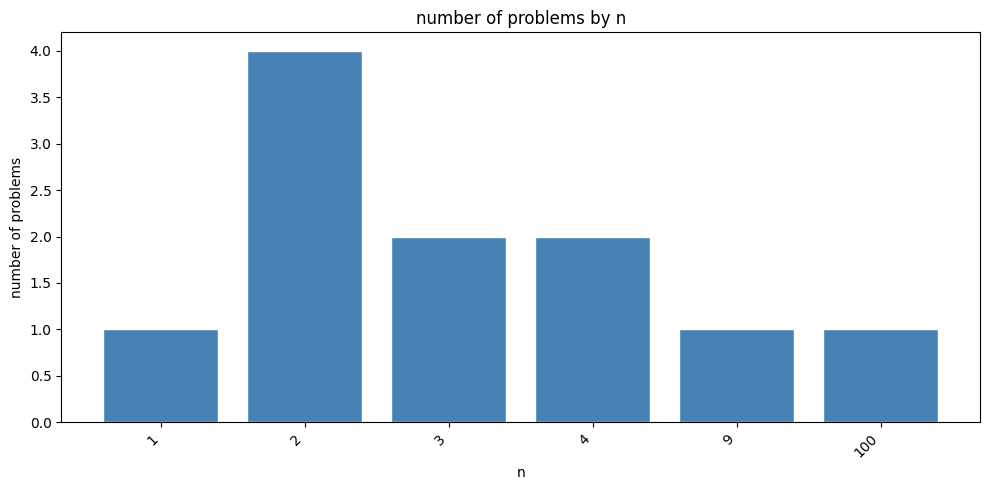

In [16]:
from collections import Counter 
import matplotlib.pyplot as plt

def count_problems_by_n(filepath: str) -> None:
    counter = Counter()
 
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('|')
            if len(parts) < 4:
                continue
            try:
                n = int(parts[3].strip())
                counter[n] += 1
            except ValueError:
                continue  # skip header or malformed lines
 
    print(f"{'n':>6} {'num_problems':>12}")
    print("-" * 20)
    for n in sorted(counter):
        print(f"{n:>6} {counter[n]:>12}")
 
    ns = sorted(counter)
    counts = [counter[n] for n in ns]
 
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar([str(n) for n in ns], counts, color="steelblue", edgecolor="white")
    ax.set_xlabel("n")
    ax.set_ylabel("number of problems")
    ax.set_title("number of problems by n")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

count_problems_by_n("hyperparam_tuning/cutest_problem_selection_hyperparam_tuning.txt")

<!-- # Algorithm Wrappers -->

In [6]:
import time
import os

TIME_LIMIT_S = 600.0

def read_last_fx(filename):
    last_fx = None
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            # Skip header and empty lines
            if not line or line.startswith("k"):
                continue
            parts = [p.strip() for p in line.split("|")]
            if len(parts) >= 3:
                try:
                    last_fx = float(parts[2])
                except ValueError:
                    pass
    return last_fx

In [7]:
def gps_path_batch_constrained(problem_idx, num_cpus, k, k_ratio, delta, tao, n_batch_calls_limit, opportunistic=True):
    log_file_path = f"alg_logs/GPS/profile_testing_{problem_idx}_cpus{num_cpus}_kr{k_ratio:.2f}_{delta:.2f}_{tao:.2f}_{n_batch_calls_limit}_{'opp' if opportunistic else 'com'}_gps.txt"
    if os.path.exists(log_file_path):
        return log_file_path
    
    GPS_expl_k_fail_wrapper = BB_wrapper.BB_k_fail_wrapper(cutest_wrapper.problem_functions[problem_idx], k*torch.ones((1024, 2), dtype=torch.int16), num_cpus)
    alg = k_fail_GPS.GPS_k_fail(torch.from_numpy(cutest_wrapper.problems[problem_idx].x0), GPS_expl_k_fail_wrapper, delta, tao, prediction_software=k_fail_prediction.constant_prediction_software(k), log_file_path=log_file_path, use_opportunistic_cpu_exploitation=opportunistic) # are true by default

    alg.log_current(message=f"k={k}")
    
    start_time = time.time()

    while alg.n_batch_calls < n_batch_calls_limit:
        if time.time() - start_time >= TIME_LIMIT_S:
            with open("alg_logs/GPS/timeout_list.txt", "a") as f:
                f.write(f"TIME LIMIT REACHED ON: {problem_idx} | {cutest_wrapper.problems[problem_idx]} | x_k = {alg.x} | f(x) = {alg.cur_f_val}\n")
            break
        alg.step_default(random_rotate=True)
    
    return log_file_path

In [8]:
def mbtr_path_batch_constrained(problem_idx, num_cpus, k, k_ratio, delta, mu, eta, gamma, eps_stop, opportunistic_cpu_exploitation_manual_point_limit, preferred_model_order, n_batch_calls_limit, opportunistic=True, orthogonal=True):
    log_file_path = f"alg_logs/MBTR/profile_testing_{problem_idx}_cpus{num_cpus}_kr{k_ratio:.2f}_{delta:.2f}_{mu:.2f}_{eta:.2f}_{gamma:.2f}_{eps_stop:.2f}_{preferred_model_order}_{opportunistic_cpu_exploitation_manual_point_limit}_{n_batch_calls_limit}_{'opp' if opportunistic else 'com'}_{'orth' if orthogonal else 'rand'}_mbtr.txt"
    if os.path.exists(log_file_path):
        return log_file_path

    MBTR_expl_k_fail_wrapper = BB_wrapper.BB_k_fail_wrapper(cutest_wrapper.problem_functions[problem_idx], k*torch.ones((1024, 2), dtype=torch.int16), num_cpus)

    alg = k_fail_MBTR.MBTR_k_fail(torch.from_numpy(cutest_wrapper.problems[problem_idx].x0), MBTR_expl_k_fail_wrapper, delta, mu, eta, gamma, eps_stop, prediction_software=k_fail_prediction.constant_prediction_software(k), log_file_path=log_file_path,
                                  preferred_model_order=preferred_model_order,
                                  opportunistic_cpu_exploitation_manual_point_limit=opportunistic_cpu_exploitation_manual_point_limit,
                                  use_opportunistic_cpu_exploitation=opportunistic,
                                  use_orthogonal=orthogonal)
    
    alg.log_current()

    start_time = time.time()

    while alg.n_batch_calls < n_batch_calls_limit:
        if time.time() - start_time >= TIME_LIMIT_S:
            with open("alg_logs/MBTR/timeout_list.txt", "a") as f:
                f.write(f"TIME LIMIT REACHED ON: {problem_idx} | {cutest_wrapper.problems[problem_idx]} | x_k = {alg.x} | f(x) = {alg.cur_f_val}\n")
            break
        alg.step_default()
    
    return log_file_path

In [9]:
def mbtr_gps_hybrid_path_batch_constrained(problem_idx, num_cpus, k, k_ratio, delta, mu, eta, gamma, eps_stop, opportunistic_cpu_exploitation_manual_point_limit, preferred_model_order, n_batch_calls_limit, opportunistic=True, orthogonal=True):
    log_file_path = f"alg_logs/MBTR_GPS_hybrid/profile_testing_{problem_idx}_cpus{num_cpus}_kr{k_ratio:.2f}_{delta:.2f}_{mu:.2f}_{eta:.2f}_{gamma:.2f}_{eps_stop:.2f}_{preferred_model_order}_{opportunistic_cpu_exploitation_manual_point_limit}_{n_batch_calls_limit}_{'opp' if opportunistic else 'com'}_{'orth' if orthogonal else 'rand'}__mbtr.txt"
    if os.path.exists(log_file_path):
        return log_file_path

    MBTR_expl_k_fail_wrapper = BB_wrapper.BB_k_fail_wrapper(cutest_wrapper.problem_functions[problem_idx], k*torch.ones((1024, 2), dtype=torch.int16), num_cpus)

    alg = k_fail_GPS_MBTR_hybrid.MBTR_GPS_hybrid_k_fail(torch.from_numpy(cutest_wrapper.problems[problem_idx].x0), MBTR_expl_k_fail_wrapper, delta, mu, eta, gamma, eps_stop, prediction_software=k_fail_prediction.constant_prediction_software(k), log_file_path=log_file_path,
                                  preferred_model_order=preferred_model_order,
                                  opportunistic_cpu_exploitation_manual_point_limit=opportunistic_cpu_exploitation_manual_point_limit,
                                  use_opportunistic_cpu_exploitation=opportunistic,
                                  use_orthogonal=orthogonal)
    
    alg.log_current()

    start_time = time.time()

    while alg.n_batch_calls < n_batch_calls_limit:
        if time.time() - start_time >= TIME_LIMIT_S:
            with open("alg_logs/MBTR_GPS_hybrid/timeout_list.txt", "a") as f:
                f.write(f"TIME LIMIT REACHED ON: {problem_idx} | {cutest_wrapper.problems[problem_idx]} | x_k = {alg.x} | f(x) = {alg.cur_f_val}\n")
            break
        alg.step_default()
    
    return log_file_path

# GPS and MBTR hyperparameters and cluster settings

In [ ]:
# cluster
# number of cpus will be determined for each problem manually
# num_cpus_dim_brackets = [
#     [4, 4], # n < 4 -> 4 cpus
#     [8, 8],
#     [16, 16],
#     [32, 32],
#     [64, 64],
#     [128, 128],
# ]
num_cpus_dim_brackets = [
    [4, 8], # n < 4 -> 4 cpus
    [16, 32],
    [64, 128],
]
k_ratios = [ # portion of cpus failing, will be rounded up
    0.0,
    0.05,
    0.1,
    0.2,
]


# GPS
gps_delta = 1.0
gps_tau = 0.5

# MBTR ORDER 1
mbtr_1_delta = 1.0
mbtr_1_mu = 1.5 # 1.0
mbtr_1_eta = 0.1
mbtr_1_gamma = 0.5
mbtr_1_eps_stop = 0.0

# MBTR ORDER 2
mbtr_2_delta = 1.0
mbtr_2_mu = 1.5 # 1.0
mbtr_2_eta = 0.1
mbtr_2_gamma = 0.5
mbtr_2_eps_stop = 0.0

# MBTR function limit
mbtr_model_function_lim = lambda n: 6*n

# Run the algorithms

In [23]:
from IPython.display import clear_output
from tqdm.notebook import tqdm
import math

log_paths = [[] for _ in range(NUM_ALGS)]

In [24]:
# GPS
alg_path_idx = 0

pbar = tqdm(total=NUM_PROBLEMS * len(k_ratios))

for problem_idx in range(NUM_PROBLEMS):
    for k_ratio_idx in range(len(k_ratios)):
        problem_n = cutest_wrapper.problems[problem_idx].n

        num_cpus = num_cpus_dim_brackets[0][1]
        for dim, cpus in num_cpus_dim_brackets:
            num_cpus = cpus
            if dim > problem_n:
                break
        
        k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

        log_paths[alg_path_idx].append(gps_path_batch_constrained(problem_idx, num_cpus, k, k_ratios[k_ratio_idx], gps_delta, gps_tau, batch_limit_func(problem_n)))

        clear_output(wait=True)
        pbar.update(1)

pbar.close()

  0%|          | 0/96 [00:00<?, ?it/s]

In [25]:
# MBTR ORDER 1
alg_path_idx = 1

pbar = tqdm(total=NUM_PROBLEMS * len(k_ratios))

for problem_idx in range(NUM_PROBLEMS):
    for k_ratio_idx in range(len(k_ratios)):
        problem_n = cutest_wrapper.problems[problem_idx].n

        num_cpus = num_cpus_dim_brackets[0][1]
        for dim, cpus in num_cpus_dim_brackets:
            num_cpus = cpus
            if dim > problem_n:
                break
        
        k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

        log_paths[alg_path_idx].append(mbtr_path_batch_constrained(problem_idx, num_cpus, k, k_ratios[k_ratio_idx], mbtr_1_delta, mbtr_1_mu, mbtr_1_eta, mbtr_1_gamma, mbtr_1_eps_stop, mbtr_model_function_lim(problem_n), 1, batch_limit_func(problem_n)))

        clear_output(wait=True)
        pbar.update(1)

pbar.close()

  0%|          | 0/96 [00:00<?, ?it/s]

In [26]:
# MBTR ORDER 2
alg_path_idx = 2

pbar = tqdm(total=NUM_PROBLEMS * len(k_ratios))

for problem_idx in range(NUM_PROBLEMS):
    for k_ratio_idx in range(len(k_ratios)):
        problem_n = cutest_wrapper.problems[problem_idx].n

        num_cpus = num_cpus_dim_brackets[0][1]
        for dim, cpus in num_cpus_dim_brackets:
            num_cpus = cpus
            if dim > problem_n:
                break
        
        k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

        log_paths[alg_path_idx].append(mbtr_path_batch_constrained(problem_idx, num_cpus, k, k_ratios[k_ratio_idx], mbtr_2_delta, mbtr_2_mu, mbtr_2_eta, mbtr_2_gamma, mbtr_2_eps_stop, mbtr_model_function_lim(problem_n), 2, batch_limit_func(problem_n)))

        clear_output(wait=True)
        pbar.update(1)

pbar.close()

  0%|          | 0/96 [00:00<?, ?it/s]

# GPS-C
alg_path_idx = 3

pbar = tqdm(total=NUM_PROBLEMS * len(k_ratios))

for problem_idx in range(NUM_PROBLEMS):
    for k_ratio_idx in range(len(k_ratios)):
        problem_n = cutest_wrapper.problems[problem_idx].n

        num_cpus = num_cpus_dim_brackets[0][1]
        for dim, cpus in num_cpus_dim_brackets:
            num_cpus = cpus
            if dim > problem_n:
                break
        
        k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

        log_paths[alg_path_idx].append(gps_path_batch_constrained(problem_idx, num_cpus, k, k_ratios[k_ratio_idx], gps_delta, gps_tau, N_BATCH_LIMIT, opportunistic=False))

        clear_output(wait=True)
        pbar.update(1)

pbar.close()

# MBTR ORDER 1 - C
alg_path_idx = 4

pbar = tqdm(total=NUM_PROBLEMS * len(k_ratios))

for problem_idx in range(NUM_PROBLEMS):
    for k_ratio_idx in range(len(k_ratios)):
        problem_n = cutest_wrapper.problems[problem_idx].n

        num_cpus = num_cpus_dim_brackets[0][1]
        for dim, cpus in num_cpus_dim_brackets:
            num_cpus = cpus
            if dim > problem_n:
                break
        
        k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

        log_paths[alg_path_idx].append(mbtr_path_batch_constrained(problem_idx, num_cpus, k, k_ratios[k_ratio_idx], mbtr_1_delta, mbtr_1_mu, mbtr_1_eta, mbtr_1_gamma, mbtr_1_eps_stop, mbtr_model_function_lim(problem_n), 1, batch_limit_func(problem_n), opportunistic=False))

        clear_output(wait=True)
        pbar.update(1)

pbar.close()

# MBTR ORDER 2 - C
alg_path_idx = 5

pbar = tqdm(total=NUM_PROBLEMS * len(k_ratios))

for problem_idx in range(NUM_PROBLEMS):
    for k_ratio_idx in range(len(k_ratios)):
        problem_n = cutest_wrapper.problems[problem_idx].n

        num_cpus = num_cpus_dim_brackets[0][1]
        for dim, cpus in num_cpus_dim_brackets:
            num_cpus = cpus
            if dim > problem_n:
                break
        
        k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

        log_paths[alg_path_idx].append(mbtr_path_batch_constrained(problem_idx, num_cpus, k, k_ratios[k_ratio_idx], mbtr_2_delta, mbtr_2_mu, mbtr_2_eta, mbtr_2_gamma, mbtr_2_eps_stop, mbtr_model_function_lim(problem_n), 2, batch_limit_func(problem_n), opportunistic=False))

        clear_output(wait=True)
        pbar.update(1)

pbar.close()

In [27]:
# MBTR GPS hybrid ORDER 1
alg_path_idx = 3

pbar = tqdm(total=NUM_PROBLEMS * len(k_ratios))

for problem_idx in range(NUM_PROBLEMS):
    for k_ratio_idx in range(len(k_ratios)):
        problem_n = cutest_wrapper.problems[problem_idx].n

        num_cpus = num_cpus_dim_brackets[0][1]
        for dim, cpus in num_cpus_dim_brackets:
            num_cpus = cpus
            if dim > problem_n:
                break
        
        k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

        log_paths[alg_path_idx].append(mbtr_gps_hybrid_path_batch_constrained(problem_idx, num_cpus, k, k_ratios[k_ratio_idx], mbtr_1_delta, mbtr_1_mu, mbtr_1_eta, mbtr_1_gamma, mbtr_1_eps_stop, mbtr_model_function_lim(problem_n), 1, batch_limit_func(problem_n)))

        clear_output(wait=True)
        pbar.update(1)

pbar.close()

  0%|          | 0/96 [00:00<?, ?it/s]

In [28]:
# MBTR GPS hybrid ORDER 2
alg_path_idx = 4

pbar = tqdm(total=NUM_PROBLEMS * len(k_ratios))

for problem_idx in range(NUM_PROBLEMS):
    for k_ratio_idx in range(len(k_ratios)):
        problem_n = cutest_wrapper.problems[problem_idx].n

        num_cpus = num_cpus_dim_brackets[0][1]
        for dim, cpus in num_cpus_dim_brackets:
            num_cpus = cpus
            if dim > problem_n:
                break
        
        k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

        log_paths[alg_path_idx].append(mbtr_gps_hybrid_path_batch_constrained(problem_idx, num_cpus, k, k_ratios[k_ratio_idx], mbtr_2_delta, mbtr_2_mu, mbtr_2_eta, mbtr_2_gamma, mbtr_2_eps_stop, mbtr_model_function_lim(problem_n), 2, batch_limit_func(problem_n)))

        clear_output(wait=True)
        pbar.update(1)

pbar.close()

  0%|          | 0/96 [00:00<?, ?it/s]

In [29]:
# MBTR ORDER 1 NON ORTHOGONAL
alg_path_idx = 5

pbar = tqdm(total=NUM_PROBLEMS * len(k_ratios))

for problem_idx in range(NUM_PROBLEMS):
    for k_ratio_idx in range(len(k_ratios)):
        problem_n = cutest_wrapper.problems[problem_idx].n

        num_cpus = num_cpus_dim_brackets[0][1]
        for dim, cpus in num_cpus_dim_brackets:
            num_cpus = cpus
            if dim > problem_n:
                break
        
        k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

        log_paths[alg_path_idx].append(mbtr_path_batch_constrained(problem_idx, num_cpus, k, k_ratios[k_ratio_idx], mbtr_1_delta, mbtr_1_mu, mbtr_1_eta, mbtr_1_gamma, mbtr_1_eps_stop, mbtr_model_function_lim(problem_n), 1, batch_limit_func(problem_n), orthogonal=False))

        clear_output(wait=True)
        pbar.update(1)

pbar.close()

  0%|          | 0/96 [00:00<?, ?it/s]

In [30]:
# MBTR ORDER 2 NON ORTHOGONAL
alg_path_idx = 6

pbar = tqdm(total=NUM_PROBLEMS * len(k_ratios))

for problem_idx in range(NUM_PROBLEMS):
    for k_ratio_idx in range(len(k_ratios)):
        problem_n = cutest_wrapper.problems[problem_idx].n

        num_cpus = num_cpus_dim_brackets[0][1]
        for dim, cpus in num_cpus_dim_brackets:
            num_cpus = cpus
            if dim > problem_n:
                break
        
        k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

        log_paths[alg_path_idx].append(mbtr_path_batch_constrained(problem_idx, num_cpus, k, k_ratios[k_ratio_idx], mbtr_2_delta, mbtr_2_mu, mbtr_2_eta, mbtr_2_gamma, mbtr_2_eps_stop, mbtr_model_function_lim(problem_n), 2, batch_limit_func(problem_n), orthogonal=False))

        clear_output(wait=True)
        pbar.update(1)

pbar.close()

  0%|          | 0/96 [00:00<?, ?it/s]

In [31]:
# MBTR GPS hybrid ORDER 1 NON ORTHOGONAL
alg_path_idx = 7

pbar = tqdm(total=NUM_PROBLEMS * len(k_ratios))

for problem_idx in range(NUM_PROBLEMS):
    for k_ratio_idx in range(len(k_ratios)):
        problem_n = cutest_wrapper.problems[problem_idx].n

        num_cpus = num_cpus_dim_brackets[0][1]
        for dim, cpus in num_cpus_dim_brackets:
            num_cpus = cpus
            if dim > problem_n:
                break
        
        k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

        log_paths[alg_path_idx].append(mbtr_gps_hybrid_path_batch_constrained(problem_idx, num_cpus, k, k_ratios[k_ratio_idx], mbtr_1_delta, mbtr_1_mu, mbtr_1_eta, mbtr_1_gamma, mbtr_1_eps_stop, mbtr_model_function_lim(problem_n), 1, batch_limit_func(problem_n), orthogonal=False))

        clear_output(wait=True)
        pbar.update(1)

pbar.close()

  0%|          | 0/96 [00:00<?, ?it/s]

In [32]:
# MBTR GPS hybrid ORDER 2 NON ORTHOGONAL
alg_path_idx = 8

pbar = tqdm(total=NUM_PROBLEMS * len(k_ratios))

for problem_idx in range(NUM_PROBLEMS):
    for k_ratio_idx in range(len(k_ratios)):
        problem_n = cutest_wrapper.problems[problem_idx].n

        num_cpus = num_cpus_dim_brackets[0][1]
        for dim, cpus in num_cpus_dim_brackets:
            num_cpus = cpus
            if dim > problem_n:
                break
        
        k = math.ceil(num_cpus * k_ratios[k_ratio_idx])

        log_paths[alg_path_idx].append(mbtr_gps_hybrid_path_batch_constrained(problem_idx, num_cpus, k, k_ratios[k_ratio_idx], mbtr_2_delta, mbtr_2_mu, mbtr_2_eta, mbtr_2_gamma, mbtr_2_eps_stop, mbtr_model_function_lim(problem_n), 2, batch_limit_func(problem_n), orthogonal=False))

        clear_output(wait=True)
        pbar.update(1)

pbar.close()

  0%|          | 0/96 [00:00<?, ?it/s]

# Plot the results

In [33]:
import profiles

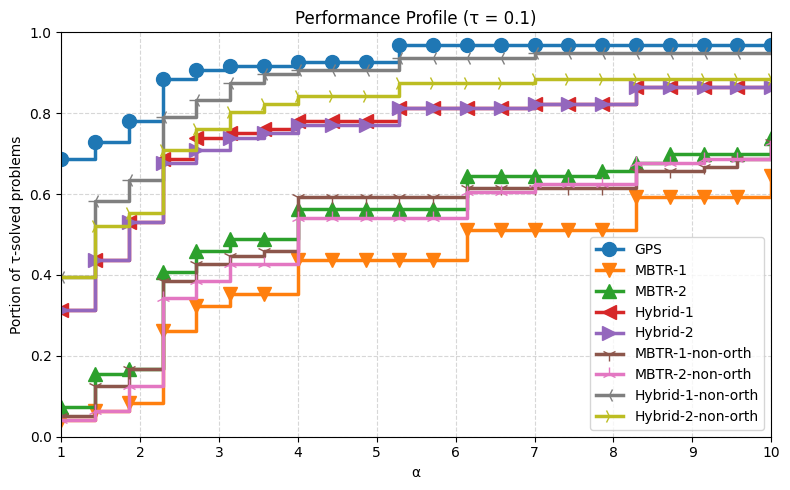

In [34]:
tau = 0.1
alpha_vals = torch.linspace(1, 10, 22)

profile_vals = profiles.performance_profile(NUM_ALGS, len(log_paths[0]), log_paths, tau, alpha_vals=alpha_vals)
profiles.plot_performance_profile(profile_vals, tau, alg_names, alpha_vals=alpha_vals)

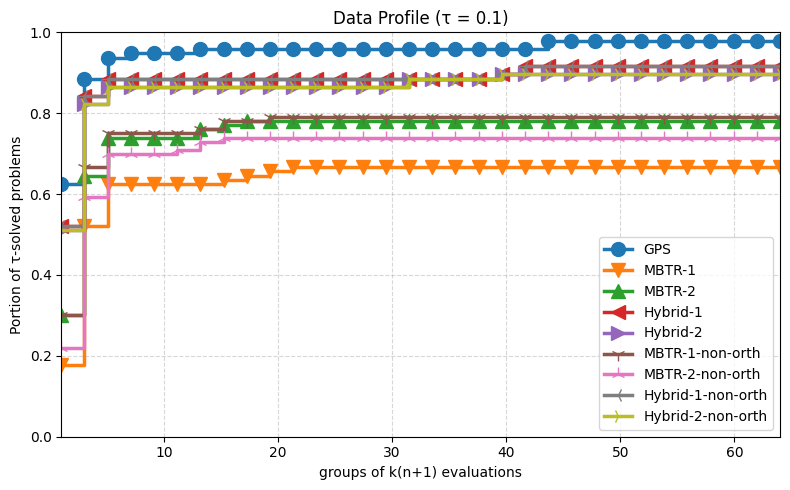

In [48]:
tau = 0.1
k_vals = torch.linspace(1, 64, 32)

problem_dims = torch.zeros(len(log_paths[0]))
for i in range(len(log_paths[0])):
    _problem_idx = int(log_paths[0][i][13:].split("_")[2])
    problem_dims[i] = cutest_wrapper.problems[_problem_idx].n

profile_vals = profiles.data_profile(NUM_ALGS, len(log_paths[0]), log_paths, tau, problem_dims, k_vals)
profiles.plot_data_profile(profile_vals, tau, alg_names, k_vals)

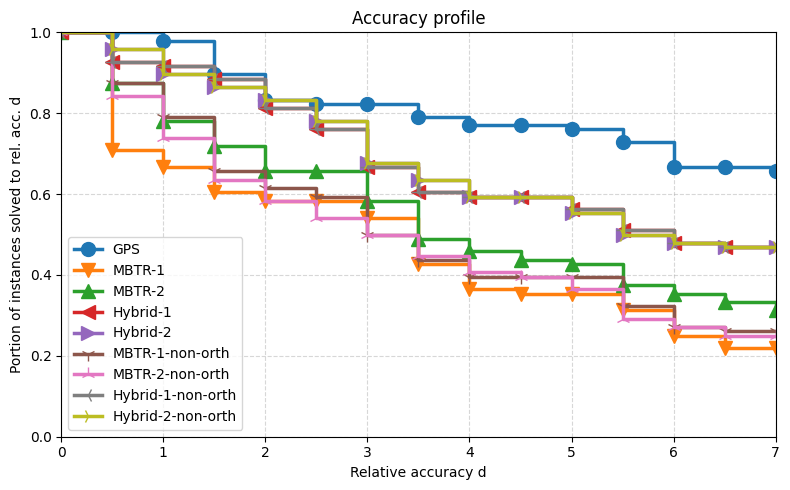

In [59]:
d_vals = torch.linspace(0, 7, 15)

profile_vals = profiles.accuracy_profile(NUM_ALGS, len(log_paths[0]), log_paths, d_vals)
profiles.plot_accuracy_profile(profile_vals, alg_names, d_vals)

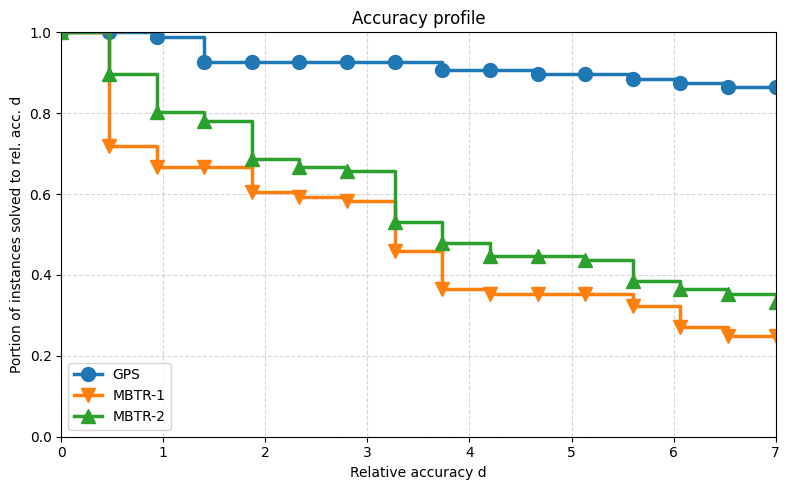

In [50]:
d_vals = torch.linspace(0, 7, 16)

profile_vals = profiles.accuracy_profile(3, len(log_paths[0]), log_paths[:3], d_vals)
profiles.plot_accuracy_profile(profile_vals, alg_names[:3], d_vals)

In [41]:
for i in range(NUM_ALGS):
    print(log_paths[i][0:4])

['alg_logs/GPS/profile_testing_0_kr0.00_1.00_0.50_160_opp_gps.txt', 'alg_logs/GPS/profile_testing_0_kr0.05_1.00_0.50_160_opp_gps.txt', 'alg_logs/GPS/profile_testing_0_kr0.10_1.00_0.50_160_opp_gps.txt', 'alg_logs/GPS/profile_testing_0_kr0.20_1.00_0.50_160_opp_gps.txt']
['alg_logs/MBTR/profile_testing_0_kr0.00_1.00_1.50_0.10_0.50_0.00_1_8_160_opp_mbtr.txt', 'alg_logs/MBTR/profile_testing_0_kr0.05_1.00_1.50_0.10_0.50_0.00_1_8_160_opp_mbtr.txt', 'alg_logs/MBTR/profile_testing_0_kr0.10_1.00_1.50_0.10_0.50_0.00_1_8_160_opp_mbtr.txt', 'alg_logs/MBTR/profile_testing_0_kr0.20_1.00_1.50_0.10_0.50_0.00_1_8_160_opp_mbtr.txt']
['alg_logs/MBTR/profile_testing_0_kr0.00_1.00_1.50_0.10_0.50_0.00_2_8_160_opp_mbtr.txt', 'alg_logs/MBTR/profile_testing_0_kr0.05_1.00_1.50_0.10_0.50_0.00_2_8_160_opp_mbtr.txt', 'alg_logs/MBTR/profile_testing_0_kr0.10_1.00_1.50_0.10_0.50_0.00_2_8_160_opp_mbtr.txt', 'alg_logs/MBTR/profile_testing_0_kr0.20_1.00_1.50_0.10_0.50_0.00_2_8_160_opp_mbtr.txt']
['alg_logs/GPS/profile_te

# Miscellaneous

In [ ]:
print(f"GPS              | MBTR-1           | MBTR-2")
for i in range(len(log_paths[0])):
    print(f"{read_last_fx(log_paths[0][i]):16.2f} | {read_last_fx(log_paths[1][i]):16.2f} | {read_last_fx(log_paths[2][i]):16.2f} # {[log_paths[_][i] for _ in range(NUM_ALGS)]}")

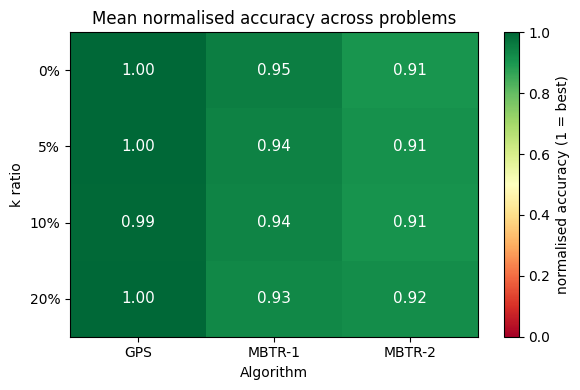

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# heatmap[k_ratio_idx, alg_idx] = mean over problems of normalised accuracy score
# score per problem = (f0 - f_algo) / (f0 - f_best), clamped to [0, 1]
# handles negative f values correctly (same formula as profiles.py)

heatmap = np.zeros((len(k_ratios), NUM_ALGS))

for k_ratio_idx in range(len(k_ratios)):
    scores = np.zeros((NUM_PROBLEMS, NUM_ALGS))
    for problem_idx in range(NUM_PROBLEMS):
        i = problem_idx * len(k_ratios) + k_ratio_idx
        f0 = profiles.parse_log_file(log_paths[0][i])["f_x"][0].item()
        f_finals = [profiles.parse_log_file(log_paths[alg_idx][i])["f_x"][-1].item() for alg_idx in range(NUM_ALGS)]
        f_best = min(f_finals)
        denom = f0 - f_best
        for alg_idx in range(NUM_ALGS):
            if abs(denom) < 1e-10:  # already optimal at start
                scores[problem_idx, alg_idx] = 1.0
            else:
                scores[problem_idx, alg_idx] = float(np.clip((f0 - f_finals[alg_idx]) / denom, 0.0, 1.0))
    heatmap[k_ratio_idx] = scores.mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(heatmap, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="normalised accuracy (1 = best)")

ax.set_xticks(range(NUM_ALGS))
ax.set_xticklabels(alg_names)
ax.set_yticks(range(len(k_ratios)))
ax.set_yticklabels([f"{r:.0%}" for r in k_ratios])
ax.set_xlabel("Algorithm")
ax.set_ylabel("k ratio")
ax.set_title("Mean normalised accuracy across problems")

for i in range(len(k_ratios)):
    for j in range(NUM_ALGS):
        ax.text(j, i, f"{heatmap[i, j]:.2f}", ha="center", va="center", fontsize=11,
                color="black" if 0.3 < heatmap[i, j] < 0.8 else "white")

plt.tight_layout()
plt.show()

In [19]:
import ast
import numpy as np
import matplotlib.pyplot as plt

def plot_x_deltas(log_path):
    xs = []
    with open(log_path, "r") as f:
        skipped_first = False
        for line in f:
            if not skipped_first or not line.strip():
                skipped_first = True
                continue
            elems = line.split("|")
            x = ast.literal_eval(elems[1].strip())
            xs.append(np.array(x))

    deltas = [np.linalg.norm(xs[i+1] - xs[i]) for i in range(len(xs) - 1)]

    plt.figure(figsize=(10, 4))
    plt.plot(deltas, drawstyle="steps-post", linewidth=1.5)
    plt.xlabel("k")
    plt.ylabel("||x_{k+1} - x_k||")
    plt.title("Distance between consecutive iterates")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

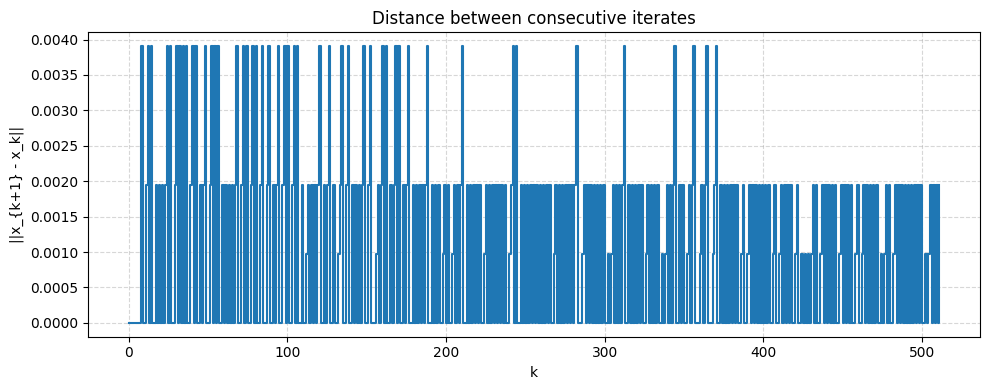

In [26]:
plot_x_deltas("alg_logs/MBTR/profile_testing_7_1.00_1.00_0.10_0.50_0.00_1_400_1024_expl_mbtr.txt")

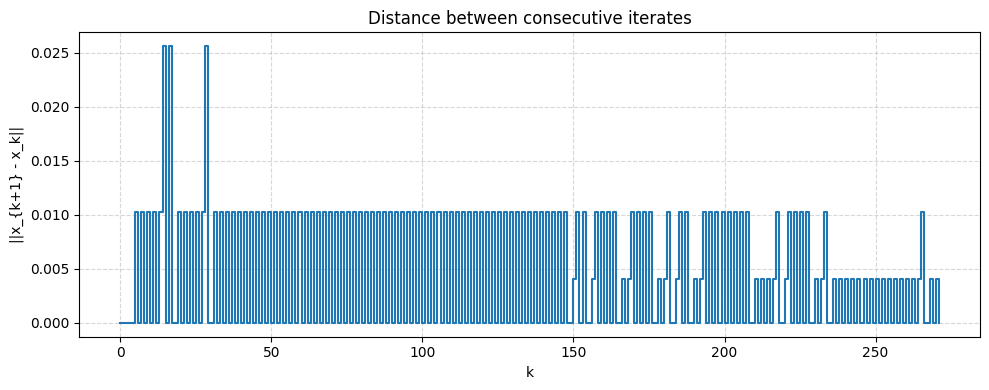

In [25]:
plot_x_deltas("alg_logs/MBTR/profile_testing_7_1.00_1.00_0.10_0.40_0.00_2_400_1024_expl_mbtr.txt")

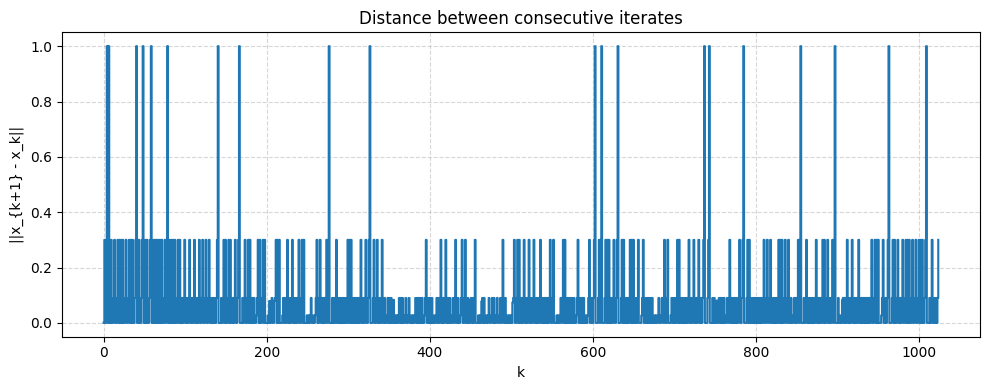

In [21]:
plot_x_deltas("alg_logs/GPS/profile_testing_7_1.00_0.30_1024_expl_gps.txt")

In [22]:
torch.log10(torch.ones(1) * 0.5)

tensor([-0.3010])